In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.core.interchange import column



In [2]:
#Load Data file
df = pd.read_excel("../data/swiggy_data.xlsx")
print(df)

            State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2                    Kengeri  Recomm

In [3]:
df.head()


,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.columns


Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [5]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [7]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [8]:
#check any null values
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [9]:
#numerical and categorical columns
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['City'] = df['City'].fillna(df['City'].fillna("Unknown"))

In [10]:
#Checking and dropping duplicate values
df = df.drop_duplicates()
df['City'].duplicated().sum()
df['Dish Name'].duplicated().sum()

np.int64(138339)

In [11]:
#Checking & fixing  Data types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Price (INR)'] = df['Price (INR)'].astype(float)



In [12]:
#Renaming column name
df = df.rename(columns={'Price (INR)': 'Price '})
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price ', 'Rating', 'Rating Count'],
      dtype='object')

In [13]:
#Order Date is not enough so to perform monthly yearly wise data
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Year'] = df['Order Date'].dt.year


KPI

In [14]:
Total_Sales = df['Price '].sum
Average_Rating = df['Rating'].mean
Average_Order_Value = df['Price '].mean
Total_Orders = df.shape[0]
Rating_Count = df['Rating Count'].count()
print(f"Total_Sales : {Total_Sales}")
print(f"Average_Rating : {Average_Rating}")
print(f"Average_Order_Value : {Average_Order_Value}")
print(f"Total_Orders : {Total_Orders}")
print(f"Rating_Count : {Rating_Count}")

Total_Sales : <bound method Series.sum of 0         133.9
1          52.0
2         117.0
3          65.0
4         130.0
          ...  
197425    112.0
197426    140.0
197427    126.0
197428     85.0
197429    100.0
Name: Price , Length: 197403, dtype: float64>
Average_Rating : <bound method Series.mean of 0         4.0
1         4.5
2         4.7
3         4.6
4         4.0
         ... 
197425    4.4
197426    4.4
197427    4.4
197428    4.4
197429    4.4
Name: Rating, Length: 197403, dtype: float64>
Average_Order_Value : <bound method Series.mean of 0         133.9
1          52.0
2         117.0
3          65.0
4         130.0
          ...  
197425    112.0
197426    140.0
197427    126.0
197428     85.0
197429    100.0
Name: Price , Length: 197403, dtype: float64>
Total_Orders : 197403
Rating_Count : 197403


Monthly sales


In [15]:
df.columns


Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price ', 'Rating', 'Rating Count', 'Month',
       'Day', 'Quarter', 'Week', 'Year'],
      dtype='object')

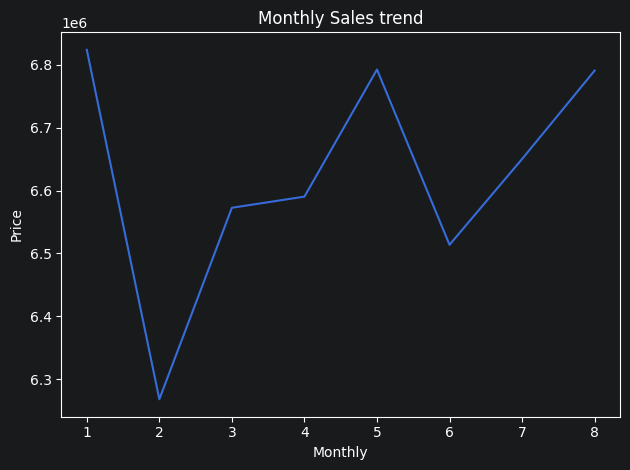

In [16]:
monthly_sales = df.groupby('Month')['Price '].sum()
monthly_sales.plot(kind ='line')
plt.title('Monthly Sales trend')

plt.xlabel('Monthly')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


Daily Sales Trend


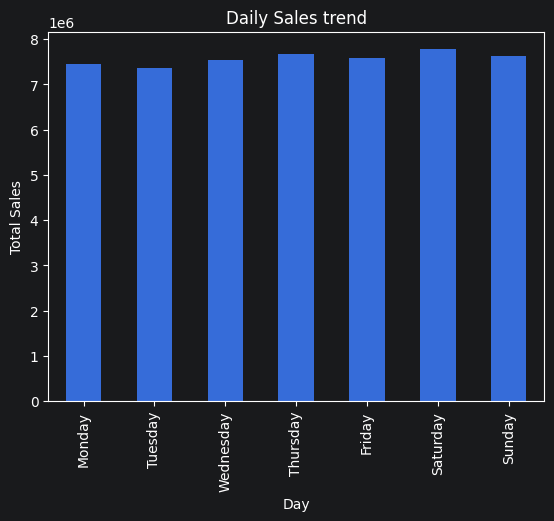

<Figure size 640x480 with 0 Axes>

In [17]:
daily_sales = df.groupby('Day')['Price '].sum()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = daily_sales.reindex(order)
daily_sales.plot(kind='bar')
plt.title('Daily Sales trend')
plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()
plt.tight_layout()
plt.show()


Total Sales by Food Types

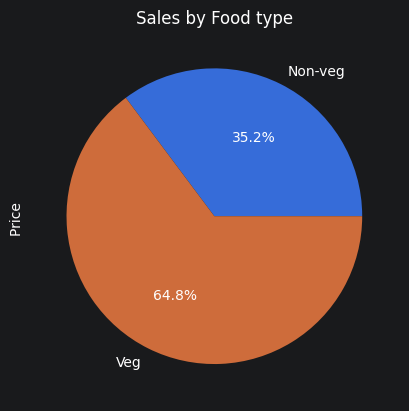

In [18]:
non_veg_keywords = ['chicken','mutton','egg','fish','prawn','biryani','kebab']
df['food type'] = df['Dish Name'].str.lower().apply(lambda x: 'Non-veg'if any(word in x for word in non_veg_keywords)else 'Veg')

#Calculating total food sales
food_sales = df.groupby('food type')['Price '].sum()
food_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title('Sales by Food type')
plt.show()

In [19]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price ', 'Rating', 'Rating Count', 'Month',
       'Day', 'Quarter', 'Week', 'Year', 'food type'],
      dtype='object')

Revenue by cuisine

In [20]:
cuisine_sales = df.groupby('Category')['Price '].sum().sort_values(ascending=False)
print(cuisine_sales)

Category
Recommended                     7188272.53
Main Course                      760045.00
Burger Combos ( 3 Pc Meals )     507773.55
McSaver Combos (2 Pc Meals)      431336.65
Desserts                         416172.28
                                   ...    
Veg Bread                            25.00
Water                                20.00
Add-ons                              16.95
Cool Drinks                          14.00
Bevarage                             10.00
Name: Price , Length: 4972, dtype: float64


In [ ]:
cuisine_sales.plot(kind='bar')
plt.title('Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()
plt.tight_layout()

/Users/akhilmadanu/PycharmProjects/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
state_sales = df.groupby('State')['Price '].sum().sort_values(ascending=False)
state_sales.plot(kind='bar',color='skyblue')
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#Quarterly wise performance summary
df['Quarter'] = df['Order Date'].dt.to_period('Q')
#Group by Quarter
Quarter_sales = df.groupby('Quarter').agg( Total_Sales=('Price ', 'sum'),
                                          Avg_Rating=('Rating', 'mean'),
                                            Total_Orders=('Order Date', 'count'))
Quarter_sales.plot(kind='bar')
plt.title('Quarter sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.show()
plt.tight_layout()



In [ ]:
top5_sales = df.groupby('City')['Price '].sum().nlargest(5)
top5_sales.plot(kind='bar',color='skyblue' )
plt.title('Top 5 sales trend')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

In [ ]:
ghhfnl;Weekly_sales = df.groupby('Week')['Price '].sum().sort_index()
Weekly_sales.plot(kind='line')
plt.title('Weekly sales trend')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()